In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, log_loss

# reproducibility
SEED = 42
np.random.seed(SEED)

# display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Data Pipeline

In [69]:
# loading and preparing the ionosphere dataset
data = fetch_openml(name="ionosphere", version=1, as_frame=True)

X = data.data.to_numpy(dtype=float)
y = data.target.to_numpy()

y = np.where(y == "g", 1, 0)

print("Dataset shape:", X.shape)
print("Class distribution:", np.bincount(y))

Dataset shape: (351, 34)
Class distribution: [126 225]


In [70]:
# perform a 70/30 split to create a training and test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

print("Training pool shape:", X_train_full.shape)
print("Test shape:", X_test.shape)

Training pool shape: (245, 34)
Test shape: (106, 34)


# Model Implementation

## Logistic Regression

In [71]:
# training function for logistic regression
def train_logistic(X_train, y_train):
    model = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=5000,
        fit_intercept=True,
        random_state=SEED
    )
    model.fit(X_train, y_train)
    return model

# evaluation function for logistic regression
def evaluate_logistic(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)
    y_test_prob = model.predict_proba(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # cross-entropy loss
    train_loss = log_loss(y_train, y_train_prob)
    test_loss = log_loss(y_test, y_test_prob)

    # generalization gap
    gap = train_acc - test_acc

    return train_acc, test_acc, train_loss, test_loss, gap

## LDA

In [72]:
# training function for linear discriminant analysis
def train_lda(X_train, y_train):
    model = LinearDiscriminantAnalysis()
    model.fit(X_train, y_train)
    return model

# evaluation function for linear discriminant analysis
def evaluate_lda(model, X_train, y_train, X_test, y_test):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        y_train_pred = model.predict(X_train)
        y_test_pred  = model.predict(X_test)
        y_train_prob = model.predict_proba(X_train)
        y_test_prob  = model.predict_proba(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test,  y_test_pred)
    train_loss = log_loss(y_train, y_train_prob)
    test_loss  = log_loss(y_test,  y_test_prob)
    gap = train_acc - test_acc

    return train_acc, test_acc, train_loss, test_loss, gap

# Experiments

## Varying Sample Size (N) and Measuring Performance

In [73]:
# ─────────────────────────────────────────────────────────────
# EXPERIMENT 1: Varying Sample Size (N), Fixed M=34
# ─────────────────────────────────────────────────────────────

sample_fracs = np.linspace(0.1, 1.0, 10)
results_n = []

for i, frac in enumerate(sample_fracs):
    n = max(int(frac * len(X_train_full)), 2)

    rng = np.random.default_rng(SEED + i)

    idx = []
    for cls in np.unique(y_train_full):
        cls_idx = np.where(y_train_full == cls)[0]
        k = max(1, round(n * len(cls_idx) / len(y_train_full)))
        k = min(k, len(cls_idx))
        idx.extend(rng.choice(cls_idx, size=k, replace=False))

    idx = np.array(idx)
    rng.shuffle(idx)

    X_sub = X_train_full[idx]
    y_sub = y_train_full[idx]

    scaler_n = StandardScaler()
    X_sub_sc = scaler_n.fit_transform(X_sub)
    X_test_sc_n = scaler_n.transform(X_test)

    lr = train_logistic(X_sub_sc, y_sub)
    lda = train_lda(X_sub_sc, y_sub)

    lr_metrics = evaluate_logistic(lr, X_sub_sc, y_sub, X_test_sc_n, y_test)
    lda_metrics = evaluate_lda(lda, X_sub_sc, y_sub, X_test_sc_n, y_test)

    results_n.append(dict(
        N=len(idx),
        M=X_sub_sc.shape[1],
        M_over_N=X_sub_sc.shape[1] / len(idx),

        lr_train_acc=lr_metrics[0],
        lr_test_acc=lr_metrics[1],
        lr_train_loss=lr_metrics[2],
        lr_test_loss=lr_metrics[3],
        lr_gap=lr_metrics[4],

        lda_train_acc=lda_metrics[0],
        lda_test_acc=lda_metrics[1],
        lda_train_loss=lda_metrics[2],
        lda_test_loss=lda_metrics[3],
        lda_gap=lda_metrics[4],
    ))

df_n = pd.DataFrame(results_n)
print("=== Varying N (stratified, reproducible) ===")
print(df_n.to_string(index=False))

=== Varying N (stratified, reproducible) ===
  N  M  M_over_N  lr_train_acc  lr_test_acc  lr_train_loss  lr_test_loss   lr_gap  lda_train_acc  lda_test_acc  lda_train_loss  lda_test_loss  lda_gap
 24 34  1.416667      1.000000     0.764151       0.000139      2.140683 0.235849       1.000000      0.764151    2.220446e-16       8.500862 0.235849
 49 34  0.693878      1.000000     0.858491       0.000156      2.149680 0.141509       1.000000      0.735849    2.220446e-16       8.269617 0.264151
 73 34  0.465753      1.000000     0.830189       0.000132      3.371758 0.169811       1.000000      0.792453    1.273004e-03       5.222425 0.207547
 98 34  0.346939      1.000000     0.905660       0.000438      1.962509 0.094340       0.979592      0.820755    1.048432e-01       2.572155 0.158837
122 34  0.278689      1.000000     0.886792       0.000145      3.137854 0.113208       0.934426      0.886792    1.772207e-01       1.246403 0.047634
147 34  0.231293      1.000000     0.811321      

## Varying Feature Dimension (M) and Measuring Performance

### Low-capacity regime with original features

In [74]:
# ─────────────────────────────────────────────────────────────
# EXPERIMENT 2.1: Varying Feature Dimension (M), Fixed N=245
# Features selected by descending variance rank so each
# increment adds the next most informative original feature
# ─────────────────────────────────────────────────────────────

feature_fracs = np.linspace(0.1, 1.0, 10)
results_m = []

# scale once on full training set — N is fixed so no leakage concern
scaler_m = StandardScaler()
X_train_sc_m = scaler_m.fit_transform(X_train_full)
X_test_sc_m  = scaler_m.transform(X_test)

# rank features by variance on training set (descending)
feature_variances = X_train_sc_m.var(axis=0)
variance_order = np.argsort(feature_variances)[::-1]  # high → low

total_features = X_train_full.shape[1]  # 34

for i, frac in enumerate(feature_fracs):
    m = max(int(frac * total_features), 1)

    # select top-m features by variance
    selected = variance_order[:m]
    X_tr_m = X_train_sc_m[:, selected]
    X_te_m = X_test_sc_m[:, selected]

    lr  = train_logistic(X_tr_m, y_train_full)
    lda = train_lda(X_tr_m, y_train_full)

    lr_metrics  = evaluate_logistic(lr,  X_tr_m, y_train_full, X_te_m, y_test)
    lda_metrics = evaluate_lda(lda,      X_tr_m, y_train_full, X_te_m, y_test)

    results_m.append(dict(
        N=len(y_train_full),
        M=m,
        M_over_N=m / len(y_train_full),

        lr_train_acc=lr_metrics[0],
        lr_test_acc=lr_metrics[1],
        lr_train_loss=lr_metrics[2],
        lr_test_loss=lr_metrics[3],
        lr_gap=lr_metrics[4],

        lda_train_acc=lda_metrics[0],
        lda_test_acc=lda_metrics[1],
        lda_train_loss=lda_metrics[2],
        lda_test_loss=lda_metrics[3],
        lda_gap=lda_metrics[4],
    ))

df_m = pd.DataFrame(results_m)
print("=== Varying M by Variance Rank (Fixed N=245) ===")
print(df_m.to_string(index=False))

=== Varying M by Variance Rank (Fixed N=245) ===
  N  M  M_over_N  lr_train_acc  lr_test_acc  lr_train_loss  lr_test_loss    lr_gap  lda_train_acc  lda_test_acc  lda_train_loss  lda_test_loss   lda_gap
245  3  0.012245      0.877551     0.915094       0.399024      0.339153 -0.037543       0.865306      0.915094        0.422502       0.357610 -0.049788
245  6  0.024490      0.861224     0.896226       0.378188      0.338199 -0.035002       0.877551      0.896226        0.408999       0.357550 -0.018675
245 10  0.040816      0.881633     0.867925       0.276971      0.298756  0.013708       0.861224      0.905660        0.331967       0.314210 -0.044436
245 13  0.053061      0.889796     0.886792       0.260630      0.283031  0.003003       0.869388      0.915094        0.324600       0.317046 -0.045707
245 17  0.069388      0.902041     0.867925       0.233353      0.309326  0.034116       0.885714      0.896226        0.308059       0.298612 -0.010512
245 20  0.081633      0.914286   

### Interpolation-focused regime with polynomial expansion

In [75]:
# ─────────────────────────────────────────────────────────────
# EXPERIMENT 2.2: Behavior near Interpolation Threshold (M ≈ N)
# Uses degree-2 polynomial expansion to push M past N=245
# Starts at M=35 to avoid overlap with Experiment 2.1
# ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import PolynomialFeatures

# scale first on full training set
scaler_interp = StandardScaler()
X_train_sc_interp = scaler_interp.fit_transform(X_train_full)
X_test_sc_interp  = scaler_interp.transform(X_test)

# degree-2 polynomial expansion: 34 features → 629 features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_sc_interp)
X_test_poly  = poly.transform(X_test_sc_interp)

total_poly_features = X_train_poly.shape[1]  # 629
n_train = len(y_train_full)                   # 245

print(f"Expanded feature space: {total_poly_features} features, N={n_train}")
print(f"Interpolation threshold at M={n_train}")

# sweep M starting from 35 (just above original feature space)
# dense sampling around threshold, sparse elsewhere
m_values = sorted(set(
    list(range(35, 100, 15)) +              # just above original features
    list(range(100, 200, 25)) +             # approaching threshold
    list(range(210, 285, 5)) +              # near threshold (dense)
    list(range(300, total_poly_features + 1, 50))  # above threshold
))

results_interp = []

for m in m_values:
    if m > total_poly_features:
        continue

    X_tr_m = X_train_poly[:, :m]
    X_te_m = X_test_poly[:, :m]

    lr  = train_logistic(X_tr_m, y_train_full)
    lda = train_lda(X_tr_m, y_train_full)

    lr_metrics  = evaluate_logistic(lr,  X_tr_m, y_train_full, X_te_m, y_test)
    lda_metrics = evaluate_lda(lda,      X_tr_m, y_train_full, X_te_m, y_test)

    results_interp.append(dict(
        N=n_train,
        M=m,
        M_over_N=m / n_train,

        lr_train_acc=lr_metrics[0],
        lr_test_acc=lr_metrics[1],
        lr_train_loss=lr_metrics[2],
        lr_test_loss=lr_metrics[3],
        lr_gap=lr_metrics[4],

        lda_train_acc=lda_metrics[0],
        lda_test_acc=lda_metrics[1],
        lda_train_loss=lda_metrics[2],
        lda_test_loss=lda_metrics[3],
        lda_gap=lda_metrics[4],
    ))

df_interp = pd.DataFrame(results_interp)
print("\n=== Interpolation Threshold (M ≈ N) ===")
print(df_interp.to_string(index=False))

Expanded feature space: 629 features, N=245
Interpolation threshold at M=245

=== Interpolation Threshold (M ≈ N) ===
  N   M  M_over_N  lr_train_acc  lr_test_acc  lr_train_loss  lr_test_loss   lr_gap  lda_train_acc  lda_test_acc  lda_train_loss  lda_test_loss  lda_gap
245  35  0.142857      0.946939     0.896226       0.108741      1.147636 0.050712       0.910204      0.886792    2.682096e-01       0.377889 0.023412
245  50  0.204082      0.946939     0.886792       0.108736      1.359318 0.060146       0.942857      0.915094    2.000736e-01       0.619187 0.027763
245  65  0.265306      0.946939     0.896226       0.108738      1.156768 0.050712       0.942857      0.886792    1.790630e-01       1.351698 0.056065
245  80  0.326531      0.946939     0.896226       0.108738      1.148972 0.050712       0.942857      0.915094    1.790630e-01       0.766269 0.027763
245  95  0.387755      0.946939     0.896226       0.108738      1.148972 0.050712       0.942857      0.915094    1.79063

## Results Across Capacity Ratio (M/N)

In [76]:
# ─────────────────────────────────────────────────────────────
# 5.3 Results Across Capacity Ratio (M/N)
# Merges df_n, df_m, df_interp and overlays on shared M/N axis
# Core question: is M/N sufficient to explain generalization?
# ─────────────────────────────────────────────────────────────

# tag each source
df_n_tagged      = df_n.copy();      df_n_tagged["source"]      = "Vary N (fix M=34)"
df_m_tagged      = df_m.copy();      df_m_tagged["source"]      = "Vary M (fix N=245)"
df_interp_tagged = df_interp.copy(); df_interp_tagged["source"] = "Interpolation (poly)"

df_all = pd.concat([df_n_tagged, df_m_tagged, df_interp_tagged], ignore_index=True)
df_all = df_all.sort_values("M_over_N").reset_index(drop=True)

print("=== Combined M/N Table ===")
print(df_all[["source", "N", "M", "M_over_N",
              "lr_test_acc", "lda_test_acc",
              "lr_gap", "lda_gap"]].to_string(index=False))

# df_all is now ready for the Results & Visualization section

=== Combined M/N Table ===
              source   N   M  M_over_N  lr_test_acc  lda_test_acc    lr_gap   lda_gap
  Vary M (fix N=245) 245   3  0.012245     0.915094      0.915094 -0.037543 -0.049788
  Vary M (fix N=245) 245   6  0.024490     0.896226      0.896226 -0.035002 -0.018675
  Vary M (fix N=245) 245  10  0.040816     0.867925      0.905660  0.013708 -0.044436
  Vary M (fix N=245) 245  13  0.053061     0.886792      0.915094  0.003003 -0.045707
  Vary M (fix N=245) 245  17  0.069388     0.867925      0.896226  0.034116 -0.010512
  Vary M (fix N=245) 245  20  0.081633     0.849057      0.905660  0.065229 -0.024028
  Vary M (fix N=245) 245  23  0.093878     0.886792      0.896226  0.039738 -0.006430
  Vary M (fix N=245) 245  27  0.110204     0.905660      0.886792  0.033115 -0.001078
  Vary M (fix N=245) 245  30  0.122449     0.867925      0.877358  0.074933  0.028764
  Vary M (fix N=245) 245  34  0.138776     0.877358      0.886792  0.069580  0.023412
   Vary N (fix M=34) 245  3

# Results & Visualization

## Performance vs Capacity Ratio (M/N)

In [77]:
# Common smoothing helper
window = 15

def smooth_curve(x, y, window=15):
    df_tmp = pd.DataFrame({"x": x, "y": y}).sort_values("x")
    y_smooth = df_tmp["y"].rolling(window).mean()
    return df_tmp["x"], y_smooth

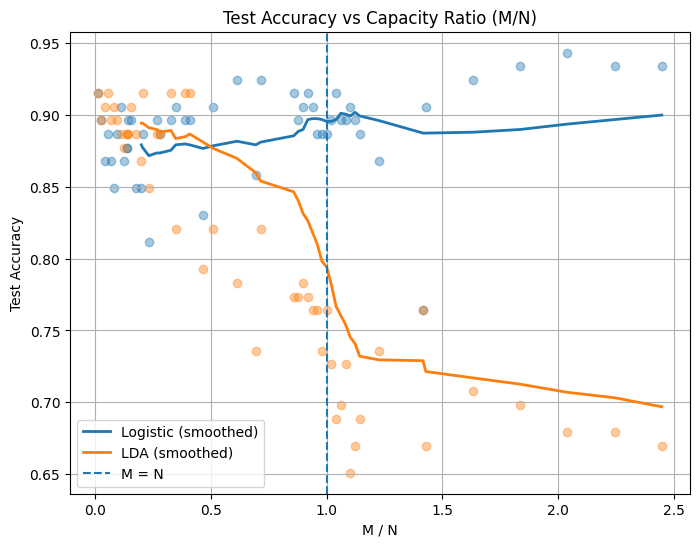

In [78]:
# Performance vs Capacity Ratio (M/N)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# scatter
plt.scatter(df_all["M_over_N"], df_all["lr_test_acc"], alpha=0.4)
plt.scatter(df_all["M_over_N"], df_all["lda_test_acc"], alpha=0.4)

# smooth
x_lr, y_lr = smooth_curve(df_all["M_over_N"], df_all["lr_test_acc"], window)
x_lda, y_lda = smooth_curve(df_all["M_over_N"], df_all["lda_test_acc"], window)

plt.plot(x_lr, y_lr, linewidth=2, label="Logistic (smoothed)")
plt.plot(x_lda, y_lda, linewidth=2, label="LDA (smoothed)")

# interpolation line
plt.axvline(x=1.0, linestyle="--", label="M = N")

plt.xlabel("M / N")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Capacity Ratio (M/N)")

plt.legend()
plt.grid(True)
plt.show()

## Generalization Gap across Models

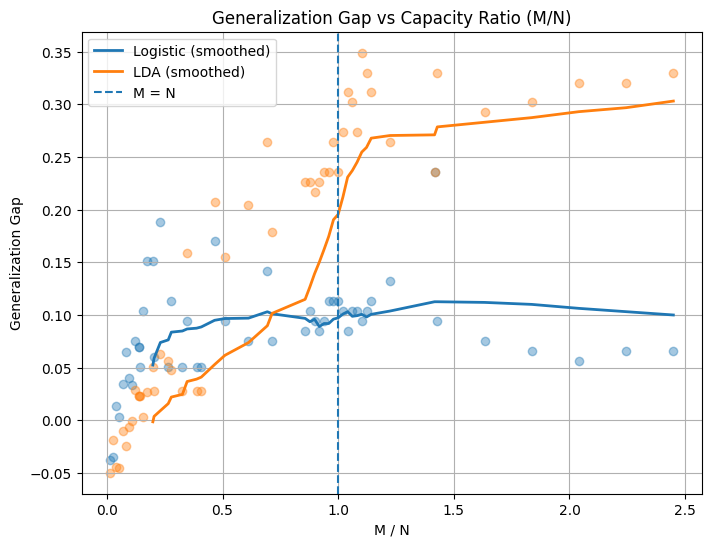

In [79]:
# Generalization Gap across Models

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# scatter
plt.scatter(df_all["M_over_N"], df_all["lr_gap"], alpha=0.4)
plt.scatter(df_all["M_over_N"], df_all["lda_gap"], alpha=0.4)

# smooth
x_lr, y_lr = smooth_curve(df_all["M_over_N"], df_all["lr_gap"], window)
x_lda, y_lda = smooth_curve(df_all["M_over_N"], df_all["lda_gap"], window)

plt.plot(x_lr, y_lr, linewidth=2, label="Logistic (smoothed)")
plt.plot(x_lda, y_lda, linewidth=2, label="LDA (smoothed)")

# interpolation line
plt.axvline(x=1.0, linestyle="--", label="M = N")

plt.xlabel("M / N")
plt.ylabel("Generalization Gap")
plt.title("Generalization Gap vs Capacity Ratio (M/N)")

plt.legend()
plt.grid(True)
plt.show()

## Behavior near Interpolation (M $\approx$ N)

In [80]:
# Behavior near Interpolation (M ≈ N)

df_near = df_all[
    (df_all["M_over_N"] > 0.7) &
    (df_all["M_over_N"] < 1.3)
]

print("Number of points near interpolation:", len(df_near))
df_near.head()

Number of points near interpolation: 17


,N,M,M_over_N,lr_train_acc,lr_test_acc,lr_train_loss,lr_test_loss,lr_gap,lda_train_acc,lda_test_acc,lda_train_loss,lda_test_loss,lda_gap,source
27,245,175,0.714286,1.0,0.924528,0.000199,1.290861,0.075472,1.0,0.820755,1.039203e-08,5.745709,0.179245,Interpolation (poly)
28,245,210,0.857143,1.0,0.915094,0.000189,1.868540,0.084906,1.0,0.773585,2.220446e-16,7.610903,0.226415,Interpolation (poly)
29,245,215,0.877551,1.0,0.896226,0.000250,1.437331,0.103774,1.0,0.773585,2.220446e-16,7.921591,0.226415,Interpolation (poly)
30,245,220,0.897959,1.0,0.905660,0.000189,1.857650,0.094340,1.0,0.783019,2.220446e-16,7.504317,0.216981,Interpolation (poly)
31,245,225,0.918367,1.0,0.915094,0.000238,1.711290,0.084906,1.0,0.773585,2.220446e-16,7.961730,0.226415,Interpolation (poly)


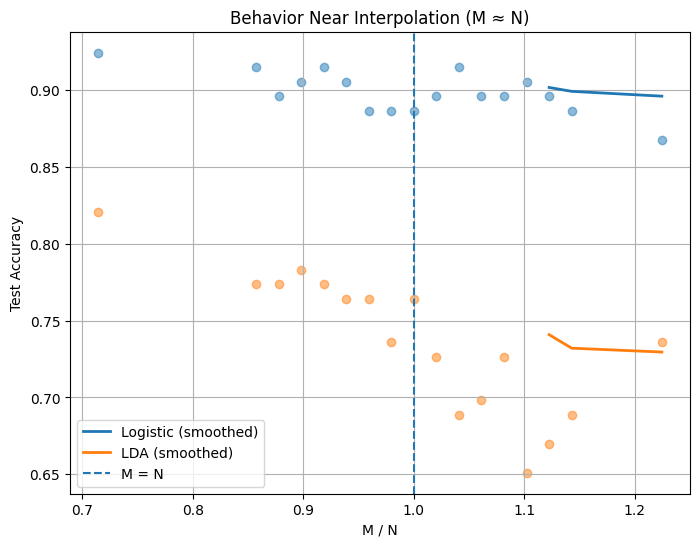

In [81]:
import matplotlib.pyplot as plt

# subset near interpolation
df_near = df_all[
    (df_all["M_over_N"] > 0.7) &
    (df_all["M_over_N"] < 1.3)
]

plt.figure(figsize=(8,6))

# scatter
plt.scatter(df_near["M_over_N"], df_near["lr_test_acc"], alpha=0.5)
plt.scatter(df_near["M_over_N"], df_near["lda_test_acc"], alpha=0.5)

# smooth
x_lr, y_lr = smooth_curve(df_near["M_over_N"], df_near["lr_test_acc"], window)
x_lda, y_lda = smooth_curve(df_near["M_over_N"], df_near["lda_test_acc"], window)

plt.plot(x_lr, y_lr, linewidth=2, label="Logistic (smoothed)")
plt.plot(x_lda, y_lda, linewidth=2, label="LDA (smoothed)")

# interpolation line
plt.axvline(x=1.0, linestyle="--", label="M = N")

plt.xlabel("M / N")
plt.ylabel("Test Accuracy")
plt.title("Behavior Near Interpolation (M ≈ N)")

plt.legend()
plt.grid(True)
plt.show()

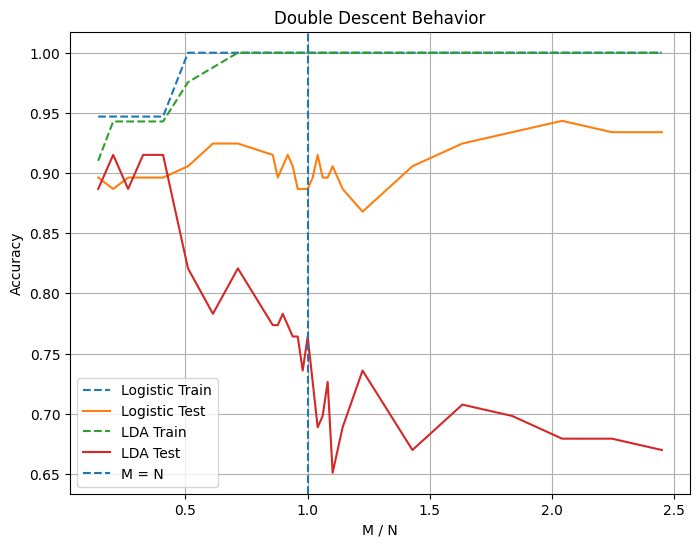

In [82]:
# Double Descent Behavior (Train vs Test)

plt.figure(figsize=(8,6))

# Logistic
plt.plot(df_interp["M_over_N"], df_interp["lr_train_acc"],
         linestyle="--", label="Logistic Train")

plt.plot(df_interp["M_over_N"], df_interp["lr_test_acc"],
         label="Logistic Test")

# LDA
plt.plot(df_interp["M_over_N"], df_interp["lda_train_acc"],
         linestyle="--", label="LDA Train")

plt.plot(df_interp["M_over_N"], df_interp["lda_test_acc"],
         label="LDA Test")

# interpolation line
plt.axvline(x=1.0, linestyle="--", label="M = N")

plt.xlabel("M / N")
plt.ylabel("Accuracy")
plt.title("Double Descent Behavior")

plt.legend()
plt.grid(True)

plt.show()